In [1]:
import os
from typing import Sequence,TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage,ToolMessage
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.graph import StateGraph, END
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv
load_dotenv()

c:\Users\Bhakti Thakur\Downloads\Agentic-AI-\agentvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
#INITIALIZE GROQ API KEY
# api_key=os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
api_key=os.environ["GROQ_API_KEY_4"]=os.getenv("GROQ_API_KEY_4")

In [3]:
#INITIALIZE SENTENCE TRANSFORMERS FOR EMBEDDINGS
model = SentenceTransformer ('BAAI/bge-large-en-v1.5')
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

In [ ]:
#Initialize MONGO DB CLIENT
from pymongo import MongoClient
client = MongoClient("mongodb+srv://xxxxxxxxxxxxxxxxxxxxxxxxxxx@cluster0.sn6fdj8.mongodb.net/?appName=Cluster0")
client.admin.command("ping")

{'ok': 1}

In [5]:
#FETCH MONGO DB COLLECTIONS
MONGO_COLLECTION =  client["sample_mflix"]["MONGODB"]
ATTN_COLLECTION =  client["sample_mflix"]["ATTN"]

In [6]:
import re
def clean_text(text: str) -> str:
    text = re.sub(r"<\s*(EOS|pad)\s*>", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\[\d+\]", "", text)
    text = re.sub(r"(Figure|Table)\s+\d+[:.]?", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s{2,}", " ", text)
    text = re.sub(r'\.{2,}', '.', text)

    return text.strip()

In [7]:


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]
    topic:str=None
    chunks: list[str]
    task_state : str=''

In [8]:
# INITIALIZE GROQ LLMS
llm1=ChatGroq(model_name="llama-3.3-70b-versatile",api_key=api_key)
llm1
llm2=ChatGroq(model_name="groq/compound",api_key=api_key)
llm2
llm3=ChatGroq(model_name="qwen/qwen3-32b",api_key=api_key)
llm3
llm4=ChatGroq(model_name="llama-3.1-8b-instant",api_key=api_key)
llm4


ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002257674C470>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002257674C980>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [9]:
# CREATE FUNCTION FOR EMBEDDINGS
def get_embedding(text):
    embeddings=model.encode(text, batch_size=3 ,normalize_embeddings=True).tolist()
    return embeddings

In [10]:
# DEFINE THE TOOLS SCOPE FOR REFERENCE
TOOL_SCOPE = """
           Available tools and their scopes:

                        TOOL NAME: get_results_mongo
                        Scope:
                        This tool should be used for answering any questions or performing tasks related to MongoDB concepts or operations. 
                        It covers all the main topics from the MongoDB Tutorialspoint PDF, including database creation, collections, 
                        Call this tool whenever the question involves MongoDB concepts.

                        1.MongoDB overview, features, advantages , collections , Document
                        2.MongoDB environment setup and usage and installation
                            1.Install MongoDB on Windows
                            2.Install MongoDB on Ubuntu
                            3.Start MongoDB
                            4.Stop MongoDB
                            5.Restart MongoDB
                            6.MongoDB Help
                            7.MongoDB Statistics

                        3.Data modeling and MongoDB datatypes
                            1.considerations while designing Schema in MongoDB
                        4.Create and drop databases in Mongo Db
                        5.Create collections in Mongo Db
                        6.MongoDB Advantages 
                            1.Advantages of MongoDB over RDBMS
                            2.Why Use MongoDB?
                            3.Where to Use MongoDB?

                        Do NOT use this tool for:
                            1.SQL databases
                            2.general programming questions
                            3.other NoSQL systems (Cassandra, Redis, etc.)
                            4. Drop Mongo DB Collections 

                        TOOL NAME: get_query_results_attn
                        Scope:
                        - "Attention Is All You Need" paper
                        - Transformer architecture
                        - Self-attention mechanism
                        - Encoder-decoder transformers
                        - Original transformer equations
                        """

CREATE AGENTS FOR WORKFLOW USING LANGCHAIN

In [12]:

#PLANNER AGENT
from langchain_core.prompts import PromptTemplate
def planner_agent_tst(state: AgentState):    
    print("--- PLAN THE STEPS FOR THE EXECUTION ---")
    print(state)
    
    query= state['topic'] 
    chunks=state['chunks']
    task_state=state['task_state']

    if task_state=='MAKE_ANOTHER_TOOL_CALL':
        org_query=state['messages'][-1].content[0]
    else:
        org_query=query
    # return org_query

    details=TOOL_SCOPE

    prompt=PromptTemplate(
            template= f""" 
                        1.You are an intelligent planner agent who is good at planning steps by breaking down a user question and understanding the details provided.
                        2.Understand user query and if the query has multiple domains , separate the query into multiple sub-questions else don't
                        3.Understand a user question {query} and {details} identify which sub questions can be answered by which tool. 
                        4.In the available tools {details} match one-to-one which tool can answer a sub-question
                        5.Once decided , Plan steps on which sub-question to be answered first and using which tool name
                        6.If the question or sub-question does not relate to any tool provided reply with 'NONE'
                        7.Once decided , strictly reply in the following formats only: 
                          For Example:
                          Question1: What is Mongo Db and what is attention mechanism?
                          

                          Reply only in this format : 'Step1': 'What is Mongo Db':'get_results_mongo'
                                                      'Step2': 'what is attention mechanism':'get_query_results_attn'
                          Question2: What is atomic theory and collections in MongoDB?
                          
                          Reply only in this format : 'Step1': 'What is atomic theory': 'NONE'
                                                      'Step2': 'collections in MongoDB': 'get_results_mongo'
 
                        8. Only reply with the steps as shown above , no extra text or explanation or your thinking steps to be added in the reply
                        

                        Points to be noted:
                        - DO NOT use external knowledge , only use details here:{details}
                        - DO NOT hallucinate any extra data in replies , Tool Scopes or invent tools
                        - DO NOT change the Tool names , the names should be an exact match.
                        - Strictly only plan further steps , do not provide any answer yourself
                        - Strictly No Thinking steps and no question to be added in the final reply

                        Here is user query: {query}
                        Here is the tool scope : {details}  
                                         
                        """,
                        input_variables=["query","details"]
        
        )
    chain=prompt | llm1
    try:
        response=chain.invoke({"query": org_query, "details": TOOL_SCOPE})
        # val= "'Step1': 'How to create a Mongo Db Database': 'get_results_mongo'\n'Step2': 'explain self attention mechanism': 'get_query_results_attn'\n'Step3': 'explain roman numeals': 'NONE'" #response.content 
        print(response.content)
        if 'MAKE_ANOTHER_TOOL_CALL' in task_state:
            print('---REPLANING DONE----')
            task_state = 'REPLANING DONE'
        else:
            print('---PLANING DONE----')
            task_state = 'PLANNING DONE'

        print({'messages': [HumanMessage(content=[org_query]+[response.content])],
        'topic': query,
        'chunks': chunks,
        'task_state' : task_state})
        
        return {
        'messages': [HumanMessage(content=[org_query]+[response.content])],#[response],
        'topic': query,
        'chunks': chunks,
        'task_state' : task_state
        
    }
    except Exception as e:
            err= f"ERROR: {repr(e)}"   
            print('---PLANING FAILED . STOPPING PROCESS----')
            return {
                'messages':[HumanMessage(content=[org_query]+[err])],
                'topic':query,
                'chunks': chunks,
                'task_state' : 'PLANNING FAILED'}
            
    
    

In [ ]:
# x=planner_agent_tst({'messages': [HumanMessage(content="What is Mongo Db and what is self attention mechanism")],'topic':'What is Mongo Db and what is self attention mechanism',
# 'chunks':[],'task_state' : 'START'})
# x

In [ ]:
# #REPLANNING
# # b=planner_agent_tst({'messages': [HumanMessage(content=['What is Mongo Db and what is self attention mechanism', 'MAKE_ANOTHER_TOOL_CALL : what is self attention mechanism'], additional_kwargs={}, response_metadata={})],
# #  'topic': 'what is self attention mechanism',
# #  'chunks': ['MongoDB 5 MongoDB is a cross-platform, document oriented database that provides, high performance, high availability, and easy scalability. MongoDB works on concept of collection and document. Database Database is a physical container for collections. Each database gets its own set of files on the file system. A single MongoDB server typically has multiple databases. Collection'],
# #  'task_state': 'VERIFICATION DONE'}
    
# # )
# # b

# b=planner_agent_tst({'messages': [HumanMessage(content=['What is Mongo Db and what is self attention mechanism', 'MAKE_ANOTHER_TOOL_CALL : self attention mechanism'], additional_kwargs={}, response_metadata={})],
#  'topic': 'self attention mechanism',
#  'chunks': ['MongoDB 5 MongoDB is a cross-platform, document oriented database that provides, high performance, high availability, and easy scalability. MongoDB works on concept of collection and document. Database Database is a physical container for collections. Each database gets its own set of files on the file system. A single MongoDB server typically has multiple databases. Collection'],
#  'task_state': 'MAKE_ANOTHER_TOOL_CALL'})
# b

In [13]:
#CREATE TOOLS CONDITION FOR ROUTING
def tools_condition(state:AgentState):

    print(f'TOOL CONDITION {state}')
    status = state['messages'][-1].content[-1]
    rs_lst=status.split('\n')
    fin=[y.replace('"','') for y in rs_lst]
    fin_lst=[x.split(':') for x in fin ]

    vals=[]
    for x in range(len(fin_lst)):
        vals.append(fin_lst[x][2].strip(" ").strip("'"))
    
    print(vals,status)
    if 'get_results_mongo' in vals:
        return 'MONGODB_TOOL'

    elif 'get_query_results_attn' in vals:
        return 'ATTENTION_TOOL'
        
    else:
        print('No Details Available ... Ending the Process')
        return 'DONE'



In [ ]:
b=tools_condition({'messages': [HumanMessage(content=['How to create database in MongoDB', "'Step1': 'How to create database in MongoDB': 'get_results_mongo'"], additional_kwargs={}, response_metadata={})], 'topic': 'How to create database in MongoDB', 'chunks': [], 'task_state': 'PLANNING DONE'})
b

In [ ]:
# b=tools_condition({'messages': [HumanMessage(content=['What is Mongo Db and what is self attention mechanism', "'Step1': 'self attention mechanism': 'get_query_results_attn'"], additional_kwargs={}, response_metadata={})],
#  'topic': 'self attention mechanism',
#  'chunks': ['MongoDB 5 MongoDB is a cross-platform, document oriented database that provides, high performance, high availability, and easy scalability. MongoDB works on concept of collection and document. Database Database is a physical container for collections. Each database gets its own set of files on the file system. A single MongoDB server typically has multiple databases. Collection'],
#  'task_state': 'REPLANING DONE'})
# b

In [14]:
#TOOL CREATED FOR MONGO DB PDF FETCHING CHUNKS FROM MOMGODB ATLAS
tool_schema = {
    "type": "object",
    "properties": {
        "query": {"type": "string"},    
    },
    "required": ["query"]
}
@tool(args_schema=tool_schema)
def get_results_mongo(query:str)-> list:
    """ 
    This tool should be used for answering any questions or performing tasks related to MongoDB concepts or operations. 
    It covers all the main topics from the MongoDB Tutorialspoint PDF, including database creation, collections, 
    CRUD operations, indexing, aggregation, replication, sharding, and backup.
    Call this tool whenever the question involves MongoDB administration, commands, or concepts.
    The tool can help with Retrieving information based on the following topics for MONGO DB:

    1.MongoDB overview, features, advantages , collections , Document
    2.MongoDB environment setup and usage and installation
      1.Install MongoDB on Windows
      2.Install MongoDB on Ubuntu
      3.Start MongoDB
      4.Stop MongoDB
      5.Restart MongoDB
      6.MongoDB Help
      7.MongoDB Statistics

    3.Data modeling and MongoDB datatypes
     1.considerations while designing Schema in MongoDB
    4.Create and drop databases in Mongo Db
    5.Create collections in Mongo Db
    6.MongoDB Advantages 
      1.Advantages of MongoDB over RDBMS
      2.Why Use MongoDB?
      3.Where to Use MongoDB?

    Do NOT use this tool for:

    1.SQL databases
    2.general programming questions
    3.other NoSQL systems (Cassandra, Redis, etc.) """
    
    query_embedding = get_embedding(query)  

    pipeline = [
        {
                "$vectorSearch": {
                "index": "MONGODB_VEC",
                "queryVector": query_embedding,
                "path": "embedding",
                "exact": False,
                "numCandidates": 100,
                "limit": 50,
                "similarity": "cosine"
                }
        }, {
                "$project": {
                "_id": 0,
                "summary": 1,
                "text": 1,
                "source": 1,
                "metadata": 1,
                "listing_url": 1,
                   "score": {
                      "$meta": "vectorSearchScore"
                   }
                }
        }
    ]

    results = MONGO_COLLECTION.aggregate(pipeline)

    array_of_results = []
    for doc in results:
      array_of_results.append(doc)

    txt=[]
    for tx in array_of_results:
        txt.append((tx['score'],clean_text(tx['text'])))

    

    return txt

In [15]:
#TOOL CREATED FOR 'ATTENTION IS ALL YOU NEED' FETCHING CHUNKS FROM MOMGODB ATLAS
@tool(args_schema=tool_schema)
def get_query_results_attn(query:str)-> list:
   """Retrieve information based on the following topics.
   1."Attention Is All You Need" paper
   2.Transformer architecture
   3.Self-attention mechanism
   4.Encoder decoder transformers
   5.Original transformer equations """
   
   query_embedding = get_embedding(query)


   pipeline = [
      {
            "$vectorSearch": {
               "index": "ATTN_VEC",
               "queryVector": query_embedding,
               "path": "embedding",
               "exact": False,
               "numCandidates": 100,
               "limit": 50,
               "similarity": "cosine"
            }
      }, {
            "$project": {
               "_id": 0,
               "text": 1,
               "source": 1,
               "metadata": 1,
               "summary": 1,
               "listing_url": 1,
               "score": {
                  "$meta": "vectorSearchScore"
               }
            }
      }
   ]

   results = ATTN_COLLECTION.aggregate(pipeline)
   # return results

   array_of_results = []
   # print(results)
   for doc in results:
      array_of_results.append(doc)
      
   
   txt=[]
   for tx in array_of_results:
        txt.append((tx['score'],clean_text(tx['text'])))

    

   return txt
   

In [22]:
#CREATE AGENTS TO WRAP THE TOOLS
import ast
def mongo_db_tool(state: AgentState):
    print("--- VERIFYING THE EMBEDDINGS FOR MONGO DB ---")
    print(f'MONGO TOOL {state}')
    query= state['topic']
    msg_resp=state['messages'][-1].content[-1]
    chunks=state['chunks']
    org_query=state['messages'][-1].content[0]
    
    rs_lst=msg_resp.split('\n')
    fin=[y.replace('"','') for y in rs_lst]
    fin_lst=[x.split(':') for x in fin ]

    vals=[]
    for x in range(len(fin_lst)):
        if fin_lst[x][2].strip(" ").strip("'") == 'get_results_mongo':
            vals.append(fin_lst[x][1].strip(" ").strip("'"))
    qts=''.join(vals)
    # return query , msg_resp , chunks , qts
 
    try:
        agent = create_agent(
        tools=[get_results_mongo] ,
        model=llm3,
        system_prompt="""You are a smart tool assistant. Using the tool specified answer the content . 
        If the context does not match with any tool description return : NO DATA AVAILABLE """
        )

        response = agent.invoke({'messages':[{'role':'user',"content":f'{qts}'}]})
        
        tool_messages = [
            m for m in response["messages"]
            if isinstance(m, ToolMessage)
        ]
        if len(tool_messages) == 0:
            ai_messages = [
            m for m in response["messages"]
            if isinstance(m, AIMessage)
            ]
            print('No Tools available')
            # return {'messages': [msg_resp]+[ai_messages]}
            return {
                    'messages':[org_query]+[ai_messages],
                    'topic':query,
                    'chunks': chunks,
                    'task_state' : 'NO DATA FETCHED'
                    }
        else:
            print('TOOLS AVAILABLE')
            results = ast.literal_eval(tool_messages[0].content)
            pair=[]
            for tx in range(len(results)):
                pair.append((query,results[tx][1]))
            rerank_scores = reranker.predict(pair)
            positive_pairs = [
                    vl for vl, score in zip(pair, rerank_scores) if score > 0
                ]
            # print(positive_pairs)
            if len(positive_pairs)==0:
                return {
                    'messages':[org_query]+['No details found'],
                    'topic':query,
                    'chunks': chunks,
                    'task_state' : 'NO DATA FETCHED'
                    }
                # return {'messages': [messages]+['No details found']}
            else:
                details=[clean_text(text) for _, text in positive_pairs]
                # chunk=' '.join(details)
                print(f'chunks before:{chunks}')
                chunks=chunks+details
                print(f'chunks after:{chunks}')
                
                
                return {
                    'messages':[HumanMessage(content=[org_query]+[msg_resp])],
                    'topic':query,
                    'chunks': chunks,
                    'task_state' : 'DATA FETCHED'
                    }
                
                
                

    except Exception as e:
        err= f"TOOL ERROR: {repr(e)}"   
        return {
                    'messages':[HumanMessage(content=[org_query]+[err])],
                    'topic':query,
                    'chunks': ['No details found'],
                    'task_state' : 'NO DATA FETCHED'
                    }
    



In [ ]:
# b=mongo_db_tool({'messages': [HumanMessage(content=['What is Mongo Db and what is self attention mechanism', "'Step1': 'What is Mongo Db': 'get_results_mongo'\n'Step2': 'what is self attention mechanism': 'get_query_results_attn'"], additional_kwargs={}, response_metadata={})],
#  'topic': 'What is Mongo Db and what is self attention mechanism',
#  'chunks': [],
#  'task_state': 'PLANNING DONE'})
# b

In [25]:
#CREATE AGENTS TO WRAP THE TOOLS
import numpy as np
import ast
def attention_paper_tool(state: AgentState):
    print("--- VERIFYING THE EMBEDDINGS : ATTENTION IS ALL YOU NEED---")    
    query=state['topic']
    chunks=state['chunks']
    msg_resp=state['messages'][-1].content[-1]
    org_query=state['messages'][-1].content[0]
    # return msg_resp
    rs_lst=msg_resp.split('\n')
    fin=[y.replace('"','') for y in rs_lst]
    fin_lst=[x.split(':') for x in fin ]

    vals=[]
    for x in range(len(fin_lst)):
        if fin_lst[x][2].strip(" ").strip("'") == 'get_query_results_attn':
            vals.append(fin_lst[x][1].strip(" ").strip("'"))
    qts=''.join(vals)

    # return qts,query,chunks,msg_resp,org_query
    
    try:
        agent = create_agent(
        tools=[get_query_results_attn],
        model=llm3,
        system_prompt="""You are a smart tool assistant. Fetch the most relevant chunks from the tools for the user query"""
        )

        response = agent.invoke({'messages':[{'role':'user',"content":f'{qts}'}]})
        
        tool_messages = [
            m for m in response["messages"]
            if isinstance(m, ToolMessage)
        ]
        if len(tool_messages) == 0:
            ai_messages = [
            m for m in response["messages"]
            if isinstance(m, AIMessage)
            ]
            print('No Tools available')
            return {'messages': [org_query]+[ai_messages]}
        else:
            print('TOOLS AVAILABLE')
            results = ast.literal_eval(tool_messages[0].content)
            pair=[]
            for tx in range(len(results)):
                pair.append((query,results[tx][1]))
            rerank_scores = reranker.predict(pair)
            positive_pairs = [
                    vl for vl, score in zip(pair, rerank_scores) if score > 0
                ]
            # print(positive_pairs)
            if len(positive_pairs)==0:
                return {
                    'messages':[HumanMessage(content=[org_query]+[msg_resp])],
                    'topic':query,
                    'chunks': ['No details found'],
                    'task_state' : 'NO DATA FETCHED'
                    }
               
            else:
                details=[clean_text(text) for _, text in positive_pairs]
                print(f'chunks before:{chunks}')
                chunks=chunks+details
                print(f'chunks after:{chunks}')
                
                return {
                    'messages':[HumanMessage(content=[org_query]+[msg_resp])],
                    'topic':query,
                    'chunks': chunks,
                    'task_state' : 'DATA FETCHED'
                    }
                
                
                

    except Exception as e:
        err= f"TOOL ERROR: {repr(e)}"   
        return {
                    'messages':[HumanMessage(content=[org_query]+[err])],
                    'topic':query,
                    'chunks': ['No details found'],
                    'task_state' : 'NO DATA FETCHED'
                    }
        



In [ ]:
# # k=attention_paper_tool({'messages': [AIMessage(content='Step1: what is self attention mechanism: get_query_results_attn', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 1742, 'total_tokens': 1757, 'completion_time': 0.047795048, 'completion_tokens_details': None, 'prompt_time': 0.091112296, 'prompt_tokens_details': None, 'queue_time': 0.056310594, 'total_time': 0.138907344}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019bd18d-5b3b-7d62-adca-c6810b520854-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1742, 'output_tokens': 15, 'total_tokens': 1757})],
# #  'topic': 'what is self attention mechanism',
# #  'chunks': ['MongoDB 5 MongoDB is a cross-platform, document oriented database that provides, high performance, high availability, and easy scalability. MongoDB works on concept of collection and document. Database Database is a physical container for collections. Each database gets its own set of files on the file system. A single MongoDB server typically has multiple databases. Collection'],
# #  'task_state': 'PLANNING DONE'})
# # k

# k=attention_paper_tool({'messages': [HumanMessage(content=['What is Mongo Db and what is self attention mechanism', "'Step1': 'self attention mechanism': 'get_query_results_attn'"], additional_kwargs={}, response_metadata={})],
#  'topic': 'self attention mechanism',
#  'chunks': ['MongoDB 5 MongoDB is a cross-platform, document oriented database that provides, high performance, high availability, and easy scalability. MongoDB works on concept of collection and document. Database Database is a physical container for collections. Each database gets its own set of files on the file system. A single MongoDB server typically has multiple databases. Collection'],
#  'task_state': 'REPLANING DONE'})
# k

In [26]:
#CREATE VERIFIER AGENT TO VERIFY THE CHUNKS FROM TOOLS
def verifier_agent(state: AgentState):
    print("--- VERIFYING THE DATA ---")
    """VERIFIER AGENT TO CHECK IF RELEVANT INFORMATION IS AVAILABLE"""
    print(f'VERIFIER STATE{state}')
    
    question = state['messages'][-1].content[0]  #"'Step1': 'How to create a Mongo Db Database': 'get_results_mongo'\n'Step2': 'explain self attention mechanism': 'get_query_results_attn'\n'Step3': 'explain roman numeals': 'NONE'"#state['messages'][0].content
    chunks= state['chunks']
    info=','.join(chunks)

   
    system_msg = SystemMessage (content= f"""
    You are an intelligent comparison agent that compares user query and chunks extracted from the tools semantically and checks if the chunks are enough to answer a query.
    Follow the below instructions:
        1.Take user query : {question} and the chunks:{info}
        2.Understand them semantically and verify if the chunks are enough to answer a user query
        3.If the chunks are incomplete or not enough to answer the query , reply strictly with the following along with the question that requires more context:
          1.'MAKE_ANOTHER_TOOL_CALL' : <question>
          Example: Question: 'What is Mongo db and what is encoder'
          Reply: 'MAKE_ANOTHER_TOOL_CALL' : what is encoder
        4.If the chunks are complete and good enough to answer the query reply strictly with the following:
          2.'GENERATE_ANSWER'
        5.Reply with either 'MAKE_ANOTHER_TOOL_CALL' : <question> or 'GENERATE_ANSWER' . Not both replies together

        Strictly follow the instructions:
          1.Do not add extra text in your reply 
          2.Do not add thinking steps 
          3.Do not hallucinate anything apart from details provided to you explicitly


        Please answer the following query
        Question:
        {question}
        by leveraging  the context provided below
        Context:
        {info}""")

    try:
        result = llm1.invoke([system_msg]+[question])
        
        if 'MAKE_ANOTHER_TOOL_CALL' in result.content:
          res=result.content
          query=res.split(':')[1].strip(' ')
          
          task_state='MAKE_ANOTHER_TOOL_CALL'
        else:
          query=question
          
          task_state='VERIFICATION DONE'

        
        return {
                    'messages':[HumanMessage(content=[question]+[result.content])],
                    'topic':query,
                    'chunks': chunks,
                    'task_state' : task_state
                    }
        

    except Exception as e:
            err= f"ERROR: {repr(e)}"   
            print('VERIFICATION PROCESS FAILED')
            return {
                    'messages':[HumanMessage(content=[question]+[err])],
                    'topic':query,
                    'chunks': chunks,
                    'task_state' : 'VERIFICATION FAILED'
                    }
            


In [27]:
#CREATE ROUTING CONDITIONS FOR VERIFIER AGENT
def verifier_condition(state:AgentState):

    # status = state['messages'][-1].content[-1]
    state=state['task_state']
        
    if 'VERIFICATION DONE' in state:
        print("--- VERIFICATION COMPLETED  ---")
        return 'GENERATE'

    elif 'MAKE_ANOTHER_TOOL_CALL' in state:
        
        print("--- DATA INSUFFICIENT RE-PLANNING  ---")
        return 'REPLAN'

    else:
        print("--- UNKNOWN STATUS . STOPPING PROCESS  ---")
        return 'DONE'

In [29]:
#CREATE GENERATOR AGENT FOR ANSWERING
def generator_agent(state: AgentState):
    print("--- GENERATING THE ANSWER ---")
    """GENERATOR AGENT TO PROVIDE RELEVANT ANSWER BY USING THE CHUNKS"""
    
    question = state['messages'][-1].content[0] #'what is mongo db and what is self attention mechanism' 
    chunks= state['chunks']
    # return(question,chunks)
    
    system_msg = SystemMessage (content= f"""
    You are an intelligent agent with good experience in understnding content and providing answers
    You can answer a user's questions in all aspects of the query asked by the user on topics of Mongo Db and the paper Attention is all you need.
    Please answer the following query
    Question:
    {question}
    by leveraging  the context provided below
    Context:
    {chunks}
    
    
    Instructions to be followed:
    -- Understand the chunks {chunks}. Provide the answer to best of your understanding of the chunks and your own knowledge.
    -- If the context does not contain information to answer the question, reply: "No data available.""
    -- Generate the answer in a detailed and concise manner covering all the aspects of the query
    -- Generate answer only relevant to the query asked
    -- Do not add any irrelevant data in the answer 
    -- Anwer should be detailed and in only 10-20 lines strictly. 

    Answer in following format :
    1.Question:{question}
    Generated Answer:
    --> Answer here                                                                                 
    """)

    result = llm2.invoke([system_msg]+[question])
    # # print(result.content)
    # result='GENERATE'
    return  {
        "messages":[result]
    }



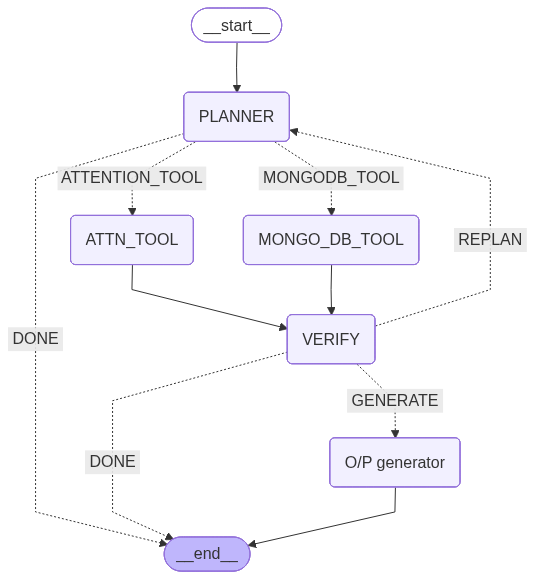

In [30]:
# CREATE FINAL WORKFLOW 

workflow=StateGraph(AgentState)
workflow.add_node("PLANNER", planner_agent_tst) 
workflow.add_node("MONGO_DB_TOOL", mongo_db_tool)
workflow.add_node("ATTN_TOOL", attention_paper_tool)
workflow.add_node("VERIFY", verifier_agent)
workflow.add_node("O/P generator", generator_agent)
workflow.set_entry_point("PLANNER")

workflow.add_conditional_edges("PLANNER",
                               tools_condition,
                               {"MONGODB_TOOL": "MONGO_DB_TOOL",
                               "ATTENTION_TOOL" : "ATTN_TOOL",
                                "DONE" : END,
                                })


workflow.add_edge("MONGO_DB_TOOL", "VERIFY")
workflow.add_edge("ATTN_TOOL", "VERIFY")

workflow.add_conditional_edges("VERIFY",
                               verifier_condition,
                               {"GENERATE": "O/P generator",
                               "REPLAN" : "PLANNER",
                               "DONE":END
                               
                                })
workflow.add_edge("O/P generator", END)
final_workflow=workflow.compile()
final_workflow

In [ ]:
# # # val={'messages': [HumanMessage(content='How to create database in MongoDB', additional_kwargs={}, response_metadata={}, id='88080a2f-182d-4c48-9a60-8b813a62b4f2'), HumanMessage(content=['How to create database in MongoDB', "'Step1': 'How to create database in MongoDB': 'get_results_mongo'"], additional_kwargs={}, response_metadata={}, id='db0f75a6-ac71-4c4e-9953-7ad114eb169f'), HumanMessage(content=['How to create database in MongoDB', "'Step1': 'How to create database in MongoDB': 'get_results_mongo'"], additional_kwargs={}, response_metadata={}, id='9d48b063-149a-420b-b1f6-027bdca81f7b'), HumanMessage(content=['How to create database in MongoDB', 'MAKE_ANOTHER_TOOL_CALL : what is use command in Mongo DB'], additional_kwargs={}, response_metadata={}, id='2484aab8-e034-4335-9c59-4bebae990527')], 'topic': 'what is use command in Mongo DB', 'chunks': ['5. MongoDB ─ Create Database . 12 6. MongoDB ─ Drop Database . 13', "MongoDB 17 In this chapter, we will see how to create a database in MongoDB. The use Command MongoDB use DATABASE_NAME is used to create database. The command will create a new database if it doesn't exist, otherwise it will return the existing database. Syntax Basic syntax of use DATABASE statement is as follows: use DATABASE_NAME Example", '7. MongoDB ─ Create Collection . 14 8. MongoDB ─ Drop Collection . 16', 'MongoDB 20 In this chapter, we will see how to create a collection using MongoDB. The createCollection() Method MongoDB db.createCollection(name, options) is used to create collection. Syntax Basic syntax of createCollection() command is as follows: db.createCollection(name, options) In the command, name is name of collection to be created. Options is a document and is', "MongoDB 19 In this chapter, we will see how to drop a database using MongoDB command. The dropDatabase() Method MongoDB db.dropDatabase() command is used to drop a existing database. Syntax Basic syntax of dropDatabase() command is as follows: db.dropDatabase() This will delete the selected database. If you have not selected any database, then it will delete default 'test' database.", 'MongoDB i About the T utorial MongoDB is an open -source document database and leading NoSQL database. MongoDB is written in C++. This tutorial will give you great understanding on MongoDB concepts needed to create and deploy a highly scalable and performance-oriented database. Audience This tutorial is designed for Software Professionals who are willing to learn MongoDB', 'MongoDB requires a data folder to store its files. The default location for the MongoDB data directory is c:\\data\\db. So you need to create this folder using the Command Prompt. Execute the following command sequence. C:\\>md data C:\\md data\\db If you have to install the MongoDB at a different location, then you need to specify an alternate', 'MongoDB 10 In the command prompt, navigate to the bin directory present in the MongoDB installation folder. Suppose my installation folder is D:\\set up\\mongodb C:\\Users\\XYZ>d: D:\\>cd "set up" D:\\set up>cd mongodb D:\\set up\\mongodb>cd bin D:\\set up\\mongodb\\bin>mongod.exe --dbpath "d:\\set up\\mongodb\\data"', '{ "ok" : 1 } > In MongoDB, you don\'t need to create collection. MongoDB creates collection automatically, when you insert some document. >db.tutorialspoint.insert({"name" : "tutorialspoint"}) >show collections mycol mycollection system.indexes tutorialspoint >', 'Database in simple and easy steps. It will throw light on MongoDB concepts and after completing this tutorial you will be at an intermediate level of expertise, from where you can take yourself at higher level of expertise. Prerequisites Before proceeding with this tutorial, you should have a basic understanding of database,', 'Your created database (mydb) is not present in list. To display database , you need to insert at least one document into it. >db.movie.insert({"name":"tutorials point"}) >show dbs local 0.78125GB mydb 0.23012GB 5. MongoDB ─ Create Database', '21. MongoDB ─ Create Backup . 43', '>db.test.find() { "_id" : ObjectId(5879b0f65a56a454), "a" : 1 } > This will show that MongoDB is installed and run successfully. Next time when you run MongoDB, you need to issue only commands. D:\\set up\\mongodb\\bin>mongod.exe --dbpath "d:\\set up\\mongodb\\data" D:\\set up\\mongodb\\bin>mongo.exe Install MongoDB on Ubuntu Run the following command to import the MongoDB public GPG key −', 'path for \\data\\db by setting the path dbpath in mongod.exe. For the same , issue the following commands. 3. MongoDB ─ Environment', "sudo apt-key adv --keyserver hkp://keyserver.ubuntu.com:80 --recv 7F0CEB10 Create a /etc/apt/sources.list.d/mongodb.list file using the following command. echo 'deb http://downloads-distro.mongodb.org/repo/ubuntu-upstart dist 10gen' | sudo tee /etc/apt/sources.list.d/mongodb.list Now issue the following command to update the repository − sudo apt-get update", 'MongoDB 5 MongoDB is a cross-platform, document oriented database that provides, high performance, high availability, and easy scalability. MongoDB works on concept of collection and document. Database Database is a physical container for collections. Each database gets its own set of files on the file system. A single MongoDB server typically has multiple databases. Collection', 'Restart MongoDB sudo service mongodb restart To use MongoDB run the following command. mongo This will connect you to running MongoDB instance. MongoDB Help To get a list of commands , type db.help() in MongoDB client. This will give you a list of commands as shown in the following screenshot.', "MongoDB 6 mysql/sqlplus mongo Sample Document Following example shows the document structure of a blog site , which is simply a comma separated key value pair. { _id: ObjectId(7df78ad8902c) title: 'MongoDB Overview', description: 'MongoDB is no sql database', by: 'tutorials point', url: 'http://www.tutorialspoint.com', tags: ['mongodb', 'database', 'NoSQL'],", 'MongoDB 9 Let us now see how to install MongoDB on Windows. Install MongoDB on Windows To install MongoDB on Windows, first download the latest release of MongoDB from http://www.mongodb.org/downloads. Make sure you get correct version of MongoDB depending upon your Windows version. To get your Windows version, open command prompt and execute the following command.', 'Example If you want to create a database with name <mydb>, then use DATABASE statement would be as follows: >use mydb switched to db mydb To check your currently selected database, use the command db >db mydb If you want to check your databases list, use the command show dbs. >show dbs local 0.78125GB test 0.23012GB', 'MongoDB 16 So while showing the data, in RDBMS you need to join three tables and in MongoDB, data will be shown from one collection only.', 'Example Suppose a client needs a database design for his blog /website and see the differences between RDBMS and MongoDB schema design. Website has the following requirements. \uf0b7 Every post has the unique title, description and url. \uf0b7 Every post can have one or more tags. \uf0b7 Every post has the name of its publisher and total number of likes.', 'MongoDB 13 MongoDB Statistics To get stats about MongoDB server, type the command db.stats() in MongoDB client. This will show the database name, number of collection and documents in the database. Output of the command is shown in the following screenshot.', 'Database Database Table Collection Tuple/Row Document column Field Table Join Embedded Documents Primary Key Primary Key (Default key _id provided by mongodb itself) Database Server and Client Mysqld/Oracle mongod 1. MongoDB ─ Overview', 'Here [version] is the version of MongoDB download. Next, open the command prompt and run the following command. C:\\>move mongodb-win64-* mongodb 1 dir(s) moved. C:\\> In case you have extracted the MongoDB at different location, then go to that path by using command cd FOOLDER/DIR and now run the above given process.', 'This will show waiting for connections message on the console output, which indicates that the mongod.exe process is running successfully. Now to run the MongoDB, you need to open another command prompt and issue the following command. D:\\set up\\mongodb\\bin>mongo.exe MongoDB shell version: 2.4.6 connecting to: test >db.test.save( { a: 1 } ) >db.test.find()', 'MongoDB 11 Next install the MongoDB by using the following command − apt-get install mongodb-10gen=2.2.3 In the above installation , 2.2.3 is currently released MongoDB version. Make sure to install the latest version always. Now MongoDB is installed successfully. Start MongoDB sudo service mongodb start Stop MongoDB sudo service mongodb stop Restart MongoDB'], 'task_state': 'MAKE_ANOTHER_TOOL_CALL'}
# # val={'messages': [HumanMessage(content='How to create database in MongoDB', additional_kwargs={}, response_metadata={}, id='88080a2f-182d-4c48-9a60-8b813a62b4f2'), HumanMessage(content=['How to create database in MongoDB', "'Step1': 'How to create database in MongoDB': 'get_results_mongo'"], additional_kwargs={}, response_metadata={}, id='db0f75a6-ac71-4c4e-9953-7ad114eb169f'), HumanMessage(content=['How to create database in MongoDB', "'Step1': 'How to create database in MongoDB': 'get_results_mongo'"], additional_kwargs={}, response_metadata={}, id='9d48b063-149a-420b-b1f6-027bdca81f7b')], 'topic': 'How to create database in MongoDB', 'chunks': ['5. MongoDB ─ Create Database . 12 6. MongoDB ─ Drop Database . 13', "MongoDB 17 In this chapter, we will see how to create a database in MongoDB. The use Command MongoDB use DATABASE_NAME is used to create database. The command will create a new database if it doesn't exist, otherwise it will return the existing database. Syntax Basic syntax of use DATABASE statement is as follows: use DATABASE_NAME Example", '7. MongoDB ─ Create Collection . 14 8. MongoDB ─ Drop Collection . 16', 'MongoDB 20 In this chapter, we will see how to create a collection using MongoDB. The createCollection() Method MongoDB db.createCollection(name, options) is used to create collection. Syntax Basic syntax of createCollection() command is as follows: db.createCollection(name, options) In the command, name is name of collection to be created. Options is a document and is', "MongoDB 19 In this chapter, we will see how to drop a database using MongoDB command. The dropDatabase() Method MongoDB db.dropDatabase() command is used to drop a existing database. Syntax Basic syntax of dropDatabase() command is as follows: db.dropDatabase() This will delete the selected database. If you have not selected any database, then it will delete default 'test' database.", 'MongoDB i About the T utorial MongoDB is an open -source document database and leading NoSQL database. MongoDB is written in C++. This tutorial will give you great understanding on MongoDB concepts needed to create and deploy a highly scalable and performance-oriented database. Audience This tutorial is designed for Software Professionals who are willing to learn MongoDB', 'MongoDB requires a data folder to store its files. The default location for the MongoDB data directory is c:\\data\\db. So you need to create this folder using the Command Prompt. Execute the following command sequence. C:\\>md data C:\\md data\\db If you have to install the MongoDB at a different location, then you need to specify an alternate', 'MongoDB 10 In the command prompt, navigate to the bin directory present in the MongoDB installation folder. Suppose my installation folder is D:\\set up\\mongodb C:\\Users\\XYZ>d: D:\\>cd "set up" D:\\set up>cd mongodb D:\\set up\\mongodb>cd bin D:\\set up\\mongodb\\bin>mongod.exe --dbpath "d:\\set up\\mongodb\\data"', '{ "ok" : 1 } > In MongoDB, you don\'t need to create collection. MongoDB creates collection automatically, when you insert some document. >db.tutorialspoint.insert({"name" : "tutorialspoint"}) >show collections mycol mycollection system.indexes tutorialspoint >', 'Database in simple and easy steps. It will throw light on MongoDB concepts and after completing this tutorial you will be at an intermediate level of expertise, from where you can take yourself at higher level of expertise. Prerequisites Before proceeding with this tutorial, you should have a basic understanding of database,', 'Your created database (mydb) is not present in list. To display database , you need to insert at least one document into it. >db.movie.insert({"name":"tutorials point"}) >show dbs local 0.78125GB mydb 0.23012GB 5. MongoDB ─ Create Database', '21. MongoDB ─ Create Backup . 43', '>db.test.find() { "_id" : ObjectId(5879b0f65a56a454), "a" : 1 } > This will show that MongoDB is installed and run successfully. Next time when you run MongoDB, you need to issue only commands. D:\\set up\\mongodb\\bin>mongod.exe --dbpath "d:\\set up\\mongodb\\data" D:\\set up\\mongodb\\bin>mongo.exe Install MongoDB on Ubuntu Run the following command to import the MongoDB public GPG key −', 'path for \\data\\db by setting the path dbpath in mongod.exe. For the same , issue the following commands. 3. MongoDB ─ Environment', "sudo apt-key adv --keyserver hkp://keyserver.ubuntu.com:80 --recv 7F0CEB10 Create a /etc/apt/sources.list.d/mongodb.list file using the following command. echo 'deb http://downloads-distro.mongodb.org/repo/ubuntu-upstart dist 10gen' | sudo tee /etc/apt/sources.list.d/mongodb.list Now issue the following command to update the repository − sudo apt-get update", 'MongoDB 5 MongoDB is a cross-platform, document oriented database that provides, high performance, high availability, and easy scalability. MongoDB works on concept of collection and document. Database Database is a physical container for collections. Each database gets its own set of files on the file system. A single MongoDB server typically has multiple databases. Collection', 'Restart MongoDB sudo service mongodb restart To use MongoDB run the following command. mongo This will connect you to running MongoDB instance. MongoDB Help To get a list of commands , type db.help() in MongoDB client. This will give you a list of commands as shown in the following screenshot.', "MongoDB 6 mysql/sqlplus mongo Sample Document Following example shows the document structure of a blog site , which is simply a comma separated key value pair. { _id: ObjectId(7df78ad8902c) title: 'MongoDB Overview', description: 'MongoDB is no sql database', by: 'tutorials point', url: 'http://www.tutorialspoint.com', tags: ['mongodb', 'database', 'NoSQL'],", 'MongoDB 9 Let us now see how to install MongoDB on Windows. Install MongoDB on Windows To install MongoDB on Windows, first download the latest release of MongoDB from http://www.mongodb.org/downloads. Make sure you get correct version of MongoDB depending upon your Windows version. To get your Windows version, open command prompt and execute the following command.', 'Example If you want to create a database with name <mydb>, then use DATABASE statement would be as follows: >use mydb switched to db mydb To check your currently selected database, use the command db >db mydb If you want to check your databases list, use the command show dbs. >show dbs local 0.78125GB test 0.23012GB', 'MongoDB 16 So while showing the data, in RDBMS you need to join three tables and in MongoDB, data will be shown from one collection only.', 'Example Suppose a client needs a database design for his blog /website and see the differences between RDBMS and MongoDB schema design. Website has the following requirements. \uf0b7 Every post has the unique title, description and url. \uf0b7 Every post can have one or more tags. \uf0b7 Every post has the name of its publisher and total number of likes.', 'MongoDB 13 MongoDB Statistics To get stats about MongoDB server, type the command db.stats() in MongoDB client. This will show the database name, number of collection and documents in the database. Output of the command is shown in the following screenshot.', 'Database Database Table Collection Tuple/Row Document column Field Table Join Embedded Documents Primary Key Primary Key (Default key _id provided by mongodb itself) Database Server and Client Mysqld/Oracle mongod 1. MongoDB ─ Overview', 'Here [version] is the version of MongoDB download. Next, open the command prompt and run the following command. C:\\>move mongodb-win64-* mongodb 1 dir(s) moved. C:\\> In case you have extracted the MongoDB at different location, then go to that path by using command cd FOOLDER/DIR and now run the above given process.', 'This will show waiting for connections message on the console output, which indicates that the mongod.exe process is running successfully. Now to run the MongoDB, you need to open another command prompt and issue the following command. D:\\set up\\mongodb\\bin>mongo.exe MongoDB shell version: 2.4.6 connecting to: test >db.test.save( { a: 1 } ) >db.test.find()', 'MongoDB 11 Next install the MongoDB by using the following command − apt-get install mongodb-10gen=2.2.3 In the above installation , 2.2.3 is currently released MongoDB version. Make sure to install the latest version always. Now MongoDB is installed successfully. Start MongoDB sudo service mongodb start Stop MongoDB sudo service mongodb stop Restart MongoDB'], 'task_state': 'DATA FETCHED'}
# # # val['messages'][-1].content[0]
# # # val['messages'][-1].content[0]  #"'Step1': 'How to create a Mongo Db Database': 'get_results_mongo'\n'Step2': 'explain self attention mechanism': 'get_query_results_attn'\n'Step3': 'explain roman numeals': 'NONE'"#state['messages'][0].content
# # val['chunks']
# #     # info=','.join(chunks)

# val={'messages': [HumanMessage(content='How to create database in MongoDB', additional_kwargs={}, response_metadata={}, id='c6a58552-5ece-43d8-ae00-84d4647e3604'),
#   HumanMessage(content=['How to create database in MongoDB', "'Step1': 'How to create database in MongoDB': 'get_results_mongo'"], additional_kwargs={}, response_metadata={}, id='84e506cb-b706-4764-9bd8-0b3648dd8c04'),
#   HumanMessage(content=['How to create database in MongoDB', "'Step1': 'How to create database in MongoDB': 'get_results_mongo'"], additional_kwargs={}, response_metadata={}, id='a8e2f57a-ecef-4099-b393-00b2458d47bf'),
#   HumanMessage(content=['How to create database in MongoDB', 'GENERATE_ANSWER'], additional_kwargs={}, response_metadata={}, id='08e51ec7-01ce-4df7-aa68-bd821ac47e06')],
#   'topic': 'How to create database in MongoDB',
#   'chunks': [],
#   'task_state': 'VERIFICATION DONE'}


In [ ]:
#SINGLE CONTEXT QUERY
response=final_workflow.invoke({'messages': [HumanMessage(content="How to create database in MongoDB")],
'topic':'How to create database in MongoDB',
'chunks':[],
'task_state' : 'START'})

--- PLAN THE STEPS FOR THE EXECUTION ---
{'messages': [HumanMessage(content='How to create database in MongoDB', additional_kwargs={}, response_metadata={}, id='872026f6-0c6c-41b7-bbc8-072354b2235f')], 'topic': 'How to create database in MongoDB', 'chunks': [], 'task_state': 'START'}
'Step1': 'How to create database in MongoDB': 'get_results_mongo'
---PLANING DONE----
{'messages': [HumanMessage(content=['How to create database in MongoDB', "'Step1': 'How to create database in MongoDB': 'get_results_mongo'"], additional_kwargs={}, response_metadata={})], 'topic': 'How to create database in MongoDB', 'chunks': [], 'task_state': 'PLANNING DONE'}
TOOL CONDITION {'messages': [HumanMessage(content='How to create database in MongoDB', additional_kwargs={}, response_metadata={}, id='872026f6-0c6c-41b7-bbc8-072354b2235f'), HumanMessage(content=['How to create database in MongoDB', "'Step1': 'How to create database in MongoDB': 'get_results_mongo'"], additional_kwargs={}, response_metadata={}, i

In [35]:
print(response['messages'][-1].content)

1. Question: How to create database in MongoDB  
Generated Answer:  
--> 1. Start the MongoDB server (`mongod`) and open the MongoDB shell (`mongo`).  
2. Switch to (or create) the desired database with the `use` command:  
   ```js
   use mydb          // replaces mydb with your database name
   ```  
   - If the database does not exist, MongoDB registers it but it will not appear in `show dbs` until it contains data.  
3. Insert at least one document into a collection (MongoDB creates the collection automatically):  
   ```js
   db.sample.insert({ name: "first document" })
   ```  
4. Verify the database was created by listing databases:  
   ```js
   show dbs
   ```  
   You should now see `mydb` with its size.  
5. Optional: explicitly create a collection before inserting data:  
   ```js
   db.createCollection("myCollection")
   ```  
   This is not required; inserting a document will create the collection automatically.  
6. Remember that MongoDB has a default `test` database; an

In [ ]:

#NO CONTEXT QUERIES
response1=final_workflow.invoke({'messages': [HumanMessage(content="what is roman numerals")],
'topic':'what is roman numerals',
'chunks':[],
'task_state' : 'START'})
print(response1['messages'][-1].content)

--- PLAN THE STEPS FOR THE EXECUTION ---
{'messages': [HumanMessage(content='what is roman numerals', additional_kwargs={}, response_metadata={}, id='9116c440-2f93-4c27-a0c2-6da0631f4910')], 'topic': 'what is roman numerals', 'chunks': [], 'task_state': 'START'}
'Step1': 'what is roman numerals': 'NONE'
---PLANING DONE----
{'messages': [HumanMessage(content=['what is roman numerals', "'Step1': 'what is roman numerals': 'NONE'"], additional_kwargs={}, response_metadata={})], 'topic': 'what is roman numerals', 'chunks': [], 'task_state': 'PLANNING DONE'}
TOOL CONDITION {'messages': [HumanMessage(content='what is roman numerals', additional_kwargs={}, response_metadata={}, id='9116c440-2f93-4c27-a0c2-6da0631f4910'), HumanMessage(content=['what is roman numerals', "'Step1': 'what is roman numerals': 'NONE'"], additional_kwargs={}, response_metadata={}, id='a1b725d9-c375-4678-b1af-481cb684efd0')], 'topic': 'what is roman numerals', 'chunks': [], 'task_state': 'PLANNING DONE'}
['NONE'] 'Step

In [ ]:
#COMPOSITE QUERY REPLANNING
response2=final_workflow.invoke({'messages': [HumanMessage(content="How to create a Mongo Db Database and explain self attention mechanism")],
'topic':'How to create a Mongo Db Database and explain self attention mechanism',
'chunks':[],
'task_state' : 'START'})


--- PLAN THE STEPS FOR THE EXECUTION ---
{'messages': [HumanMessage(content='How to create a Mongo Db Database and explain self attention mechanism', additional_kwargs={}, response_metadata={}, id='c1be314e-47b7-417d-81b8-a2ad9289bc71')], 'topic': 'How to create a Mongo Db Database and explain self attention mechanism', 'chunks': [], 'task_state': 'START'}
'Step1': 'How to create a Mongo Db Database': 'get_results_mongo'
'Step2': 'explain self attention mechanism': 'get_query_results_attn'
---PLANING DONE----
{'messages': [HumanMessage(content=['How to create a Mongo Db Database and explain self attention mechanism', "'Step1': 'How to create a Mongo Db Database': 'get_results_mongo'\n'Step2': 'explain self attention mechanism': 'get_query_results_attn'"], additional_kwargs={}, response_metadata={})], 'topic': 'How to create a Mongo Db Database and explain self attention mechanism', 'chunks': [], 'task_state': 'PLANNING DONE'}
TOOL CONDITION {'messages': [HumanMessage(content='How to cr

In [32]:
print(response2['messages'][-1].content)

1.Question:How to create a Mongo Db Database and explain self attention mechanism  
Generated Answer:  
--> • Create a data folder (e.g., C:\data\db) if it doesn’t exist.  
--> • Start the mongod server pointing to that folder.  
--> • In the mongo shell, switch to a new database with `use mydb`; MongoDB creates it on first write.  
--> • Create a collection and insert a document, e.g., `db.movies.insertOne({name:"tutorials point"})`.  
--> • Verify with `show dbs` – the database appears after the insert.  
--> • Self‑attention (intra‑attention) computes each token’s representation by weighting all other tokens in the same sequence.  
--> • Queries (Q), Keys (K), and Values (V) are linear projections of the input embeddings.  
--> • Attention scores = softmax(Q·Kᵀ / √d_k); output = Σ (score_i × V_i).  
--> • Multi‑head attention runs several such projections in parallel, capturing different relational aspects.  
--> • In Transformers, encoder layers apply full self‑attention; decoder l

In [37]:
# response3=final_workflow.invoke({'messages': [HumanMessage(content="what is encoder-decoder and explain collections in MongoDb")],
# 'topic':'what is encoder-decoder and explain collections in MongoDb',
# 'chunks':[],
# 'task_state' : 'START'})